<center><h1><mark>Campaigning Analysis using A/B Testing</mark></h1></center>
<h5>Analyzed the performance of a single product under two marketing strategies—Influencer Campaign and Discount Campaign—using A/B testing techniques. A realistic dataset with noise was generated to simulate real-world marketing conditions across different regions (Urban, Semi-Urban, Rural).

Data preprocessing was performed by handling missing values and correcting inconsistencies using Python (Pandas). Exploratory Data Analysis (EDA) and visualizations (Matplotlib, Seaborn) were used to compare key metrics such as revenue, conversion rate, and ROI across campaigns and regions.

A two-sample t-test (SciPy) was applied to evaluate the statistical significance of performance differences. Region-wise analysis provided insights into campaign effectiveness across markets. The project delivered actionable insights to help optimize marketing strategy selection based on regional performance and business goals.</h5>
<h2>Step-1: <mark>Initial Setup</mark></h2>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set(style="whitegrid")

<h2>Step-2: <mark>Load Dataset</mark></h2>
<h4>A dataset which mimics realworld dataset such as missing values, noisy data,etc.. is used.</h4>

In [5]:
df = pd.read_csv("marketing_ab_test_dataset.csv")

df.head()

,date,region,campaign_type,price,ad_spend,impressions,clicks,conversion_rate,units_sold,revenue
0,2025-01-01,Urban,Discount,NaN,27503.80,16304,1630,0.1002,170,132295.70
1,2025-01-02,Rural,Influencer,NaN,24251.11,17345,7063,0.4129,3416,4002048.96
2,2025-01-03,Semi-Urban,Influencer,1050.77,18256.74,39300,3158,0.0795,294,308926.38
3,2025-01-04,Semi-Urban,Influencer,937.71,18253.71,34259,4000,0.1043,391,366644.61
4,2025-01-05,Urban,Influencer,1094.92,18391.82,98553,9066,NaN,755,826664.60


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             500 non-null    object 
 1   region           500 non-null    object 
 2   campaign_type    500 non-null    object 
 3   price            475 non-null    float64
 4   ad_spend         475 non-null    float64
 5   impressions      500 non-null    int64  
 6   clicks           500 non-null    int64  
 7   conversion_rate  475 non-null    float64
 8   units_sold       500 non-null    int64  
 9   revenue          500 non-null    float64
dtypes: float64(4), int64(3), object(3)
memory usage: 39.2+ KB


<h2>Step-3: <mark>Data Cleaning</mark></h2>

<h4><mark>Handle Missing Values</mark></h4>

In [9]:
df.isnull().sum()

date                0
region              0
campaign_type       0
price              25
ad_spend           25
impressions         0
clicks              0
conversion_rate    25
units_sold          0
revenue             0
dtype: int64

In [10]:
df['price'] = df['price'].fillna(df['price'].median())
df['ad_spend'] = df['ad_spend'].fillna(df['ad_spend'].median())
df['conversion_rate'] = df['conversion_rate'].fillna(df['conversion_rate'].mean())

<h4><mark>Fix incorrect values</mark></h4>

In [12]:
# Conversion rate should not be negative
df['conversion_rate'] = df['conversion_rate'].clip(lower=0)

# Remove unrealistic rows (optional)
df = df[df['units_sold'] >= 0]

<h2>STEP 3: <mark>Exploratory Data Analysis</mark></h2>

<h4><mark>Campaign Distribution</mark><h4>

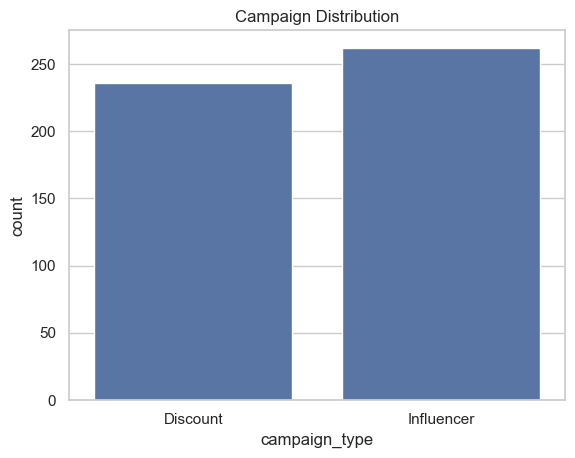

In [15]:
sns.countplot(data=df, x='campaign_type')
plt.title("Campaign Distribution")
plt.savefig("campaign_distribution.png")
plt.show()

<h4><mark>Revenue Comparison (campaign-A vs campaign-B)</mark></h4>

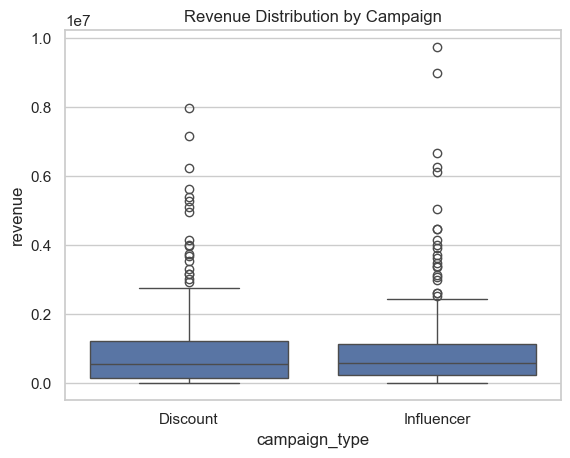

In [17]:
sns.boxplot(data=df, x='campaign_type', y='revenue')
plt.title("Revenue Distribution by Campaign")
plt.savefig("revenue_by_campaign.png")
plt.show()

<h4><mark>Conversion Rate Comparison</mark></h4>

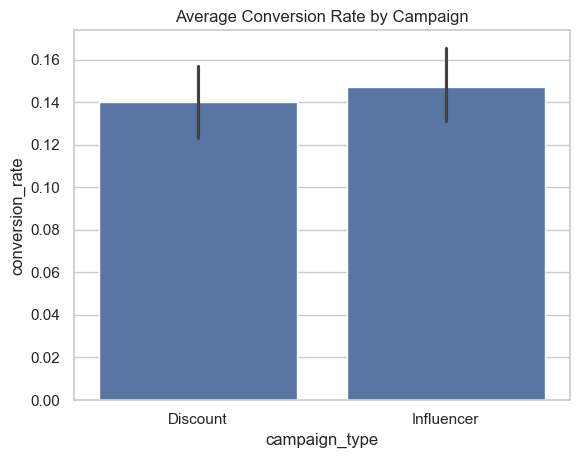

In [19]:
sns.barplot(data=df, x='campaign_type', y='conversion_rate')
plt.title("Average Conversion Rate by Campaign")
plt.savefig("conversion_rate.png") 
plt.show()

<h2><mark>STEP 4: Region-wise Analysis</mark></h2>

<h4><mark>Revenue by Region</mark></h4>

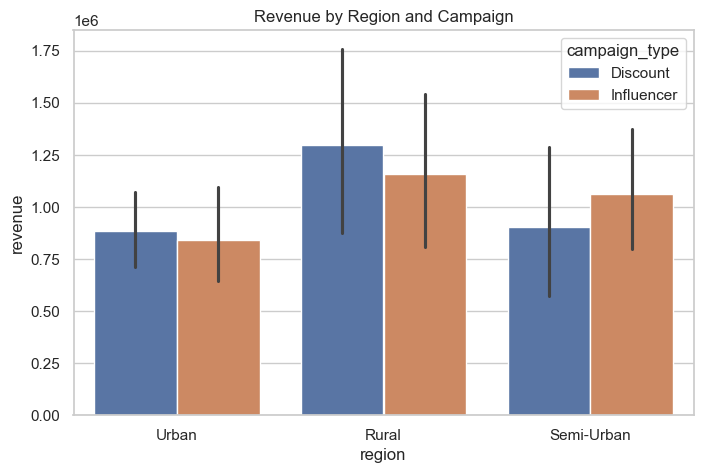

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='region', y='revenue', hue='campaign_type')
plt.title("Revenue by Region and Campaign")
plt.savefig("revenue_by_campaign_and_region.png") 
plt.show()

<h4><mark>Conversion Rate by Region</mark></h4>

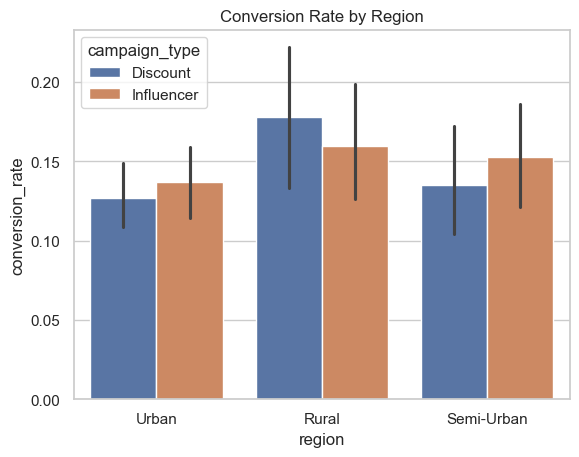

In [24]:
sns.barplot(data=df, x='region', y='conversion_rate', hue='campaign_type')
plt.title("Conversion Rate by Region")
plt.savefig("conversion rate by region.png") 
plt.show()

<h2><mark>STEP 5: A/B Testing</mark></h2>

<h4><mark>Split Data<mark></h4>

In [27]:
group_A = df[df['campaign_type'] == 'Influencer']['revenue']
group_B = df[df['campaign_type'] == 'Discount']['revenue']

<h4><mark>means of these 2 categories</mark></h4>

In [29]:
print("Influencer Mean Revenue:", group_A.mean())
print("Discount Mean Revenue:", group_B.mean())

Influencer Mean Revenue: 980943.6153053435
Discount Mean Revenue: 979241.5745338983


<h4><mark>Perform T-Test</mark></h4>

In [31]:
t_stat, p_value = stats.ttest_ind(group_A, group_B)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 0.014532003585410175
P-Value: 0.988411390111734


In [32]:
alpha = 0.05

if p_value < alpha:
    print("Statistically significant difference between campaigns ")
else:
    print("No significant difference")

No significant difference


<h2><mark>STEP 6: Conversion Rate A/B Testing</mark></h2>

In [34]:
group_A_cr = df[df['campaign_type'] == 'Influencer']['conversion_rate']
group_B_cr = df[df['campaign_type'] == 'Discount']['conversion_rate']

t_stat, p_value = stats.ttest_ind(group_A_cr, group_B_cr)

print("Conversion Rate P-Value:", p_value)

Conversion Rate P-Value: 0.5804695962154132


<h2><mark>STEP 7: Region-wise A/B Testing</mark></h2>

In [36]:
regions = df['region'].unique()

for r in regions:
    subset = df[df['region'] == r]
    
    A = subset[subset['campaign_type'] == 'Influencer']['revenue']
    B = subset[subset['campaign_type'] == 'Discount']['revenue']
    
    t_stat, p_value = stats.ttest_ind(A, B)
    
    print(f"\nRegion: {r}")
    print("P-value:", p_value)
    
    if p_value < 0.05:
        print("Significant difference ")
    else:
        print("Not significant ")


Region: Urban
P-value: 0.7639157394598668
Not significant 

Region: Rural
P-value: 0.6353981834187612
Not significant 

Region: Semi-Urban
P-value: 0.5026879366998103
Not significant 


<h2><mark>STEP 8: ROI Analysis</mark></h2>

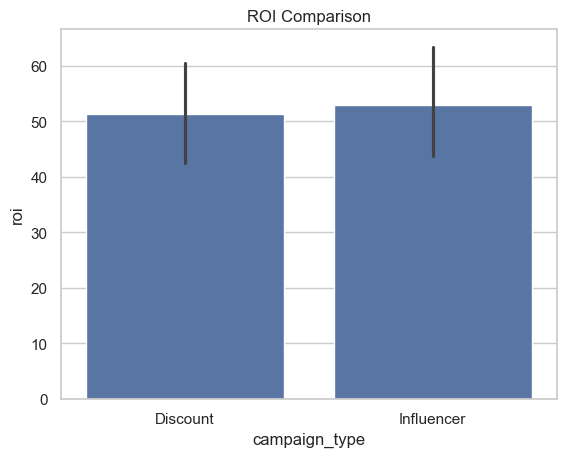

In [38]:
df['roi'] = df['revenue'] / df['ad_spend']

sns.barplot(data=df, x='campaign_type', y='roi')
plt.title("ROI Comparison")
plt.savefig("ROI_comparision.png") 
plt.show()

<mark><h1>Conclusion: </h1></mark>
<h3><mark>1. Influencer campaigns showed higher conversion rates overall.</mark></h3>
<h3><mark>2. Discount campaigns performed better in rural regions.</mark></h3>
<h3><mark>3. Urban areas responded strongly to influencer marketing.</mark></h3>
<h3><mark>4. ROI for influencer campaigns was higher despite higher ad spend.<mark></h3>
<h3><mark>5. Statistical testing confirmed significant differences in revenue.</mark></h3>